# Market Maker

Posts passive limit orders on TrueMarkets at the Coinbase BBO, resting deep inside TM's wide executable spread so any TM taker crosses us first. All fills are maker fills (5× volume multiplier). Reprices every 1.5s via CB WebSocket (zero rate-limit cost); TM executable quotes fetched once per 30s for chart display only.

In [1]:
import sys
import os
import asyncio
import math
import time
from pathlib import Path

ROOT_DIR = Path(os.getcwd()).parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import aiohttp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output
from dotenv import load_dotenv

from lib.execution import ExecutionClient
from lib.coinbase_feed import CoinbaseBookA

load_dotenv(ROOT_DIR / "keys" / ".env")

TM_REST_URL = os.getenv("BASE_REST_URL", "https://api.truemarkets.co")
TM_KEY_FILE = str(ROOT_DIR / "keys" / "truemarkets-api-key-edd1691b.json")
CB_WS_URL   = os.getenv("COINBASE_WS_URL", "wss://ws-feed.exchange.coinbase.com")
CB_PRODUCT  = "BTC-USD"
BASE_ASSET  = "BTC"
QUOTE_ASSET = "USDC"

In [2]:
import websockets
import json


class TrueMarketsBook:
    """
    Native TrueMarkets L2 order book via the DEPTH WebSocket channel.
    Endpoint: wss://api.truex.co/api/v1  — no auth required.
    """
    _WS_URL = "wss://api.truex.co/api/v1"
    _HEADERS = {
        "Origin": "https://truemarkets.co",
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36",
        "Accept-Language": "en-US,en;q=0.9",
    }

    def __init__(self, symbol="BTC-PYUSD"):
        self.symbol   = symbol
        self._bids    = {}
        self._asks    = {}
        self._seqnum  = 0
        self._ts      = 0.0
        self._ready   = False

    @property
    def best_bid(self):       return max(self._bids) if self._bids else None
    @property
    def best_ask(self):       return min(self._asks) if self._asks else None
    @property
    def best_bid_size(self):
        b = self.best_bid; return self._bids[b] if b is not None else None
    @property
    def best_ask_size(self):
        a = self.best_ask; return self._asks[a] if a is not None else None
    @property
    def mid(self):
        b, a = self.best_bid, self.best_ask
        return (b + a) / 2.0 if (b is not None and a is not None) else None
    @property
    def is_ready(self): return self._ready

    def _handle_snapshot(self, data):
        self._bids  = {float(b["price"]): float(b["qty"]) for b in data.get("bids", []) if float(b["qty"]) > 0}
        self._asks  = {float(a["price"]): float(a["qty"]) for a in data.get("asks", []) if float(a["qty"]) > 0}
        self._ready = True
        self._ts    = time.time()

    def _handle_update(self, data):
        for b in data.get("bids", []):
            p, q = float(b["price"]), float(b["qty"])
            if q == 0: self._bids.pop(p, None)
            else:      self._bids[p] = q
        for a in data.get("asks", []):
            p, q = float(a["price"]), float(a["qty"])
            if q == 0: self._asks.pop(p, None)
            else:      self._asks[p] = q
        self._ts = time.time()

    async def run(self):
        backoff = 1
        while True:
            try:
                async with websockets.connect(self._WS_URL, additional_headers=self._HEADERS) as ws:
                    backoff = 1
                    self._ready = False
                    await ws.send(json.dumps({
                        "type": "SUBSCRIBE_NO_AUTH",
                        "item_names": [self.symbol],
                        "channels": ["DEPTH"],
                        "timestamp": str(int(time.time())),
                    }))
                    async for raw in ws:
                        try: msg = json.loads(raw)
                        except Exception: continue
                        self._seqnum = msg.get("seqnum", self._seqnum)
                        t = msg.get("update")
                        d = msg.get("data", {})
                        if   t == "SNAPSHOT": self._handle_snapshot(d)
                        elif t == "UPDATE":   self._handle_update(d)
            except websockets.ConnectionClosed:
                pass
            except Exception as e:
                print(f"TrueMarketsBook error: {e}")
            self._ready = False
            await asyncio.sleep(backoff)
            backoff = min(backoff * 2, 30)


### Strategy Parameters

In [3]:
LOOP_SECS            = 3.0    # seconds per cycle (cancel+replace both sides needs ~5 req/cycle)
QUOTE_SIZE_BTC       = 0.0001 # BTC per resting order
TICK_SIZE            = 0.1    # TrueMarkets BTC price increment ($0.10)
PRICE_DECIMALS       = 1
MAX_POSITION_BTC     = 0.001  # max net BTC inventory (long or short)
DAILY_LOSS_LIMIT     = 5.0    # kill switch: stop if session PnL < -$X
PRICE_CHART_WINDOW   = 40     # cycles shown in the price subplot
MAX_STALE_ORDER_SECS = 90.0   # safety repost if an order rests this long without a fill

# TrueMarkets native book (DEPTH WebSocket)
TM_BOOK_SYMBOL    = "BTC-PYUSD"
MM_SIZE_THRESHOLD = 0.001   # min BTC at best bid/ask to quote that side
SPREAD_IMPROVE_PCT = 0.05   # fraction of TM spread to move inside per side
                             # e.g. 0.05 → new_bid = best_bid + 5% × spread


### Helpers and Plotting

In [4]:
size_str = f"{QUOTE_SIZE_BTC:.8f}".rstrip("0").rstrip(".")

def floor_tick(p): return round(math.floor(p / TICK_SIZE) * TICK_SIZE, 1)
def ceil_tick(p):  return round(math.ceil(p  / TICK_SIZE) * TICK_SIZE, 1)
def fmt_px(p):     return f"{p:.1f}"

async def get_full_balances(bot, session):
    """Returns (total_btc, total_usd, avail_btc, avail_usd).

    total includes capital locked in open orders (available + held).
    Use total for PnL so locked order collateral isn't counted as a loss.
    Use avail for order placement checks so we don't over-commit.
    """
    data = await bot._get(session, "/v1/conductor/balances")
    total_btc = avail_btc = total_usd = avail_usd = 0.0
    if not data:
        return None, None, None, None
    for b in data.get("data", []):
        sym   = b.get("symbol", "")
        avail = float(b.get("available", 0) or 0)
        held  = float(b.get("held",      0) or 0)
        if sym == BASE_ASSET:
            total_btc += avail + held
            avail_btc += avail
        elif sym in (QUOTE_ASSET, "PYUSD"):
            total_usd += avail + held
            avail_usd += avail
    return total_btc, total_usd, avail_btc, avail_usd

# ── live data series ──────────────────────────────────────────────
time_series    = []
pnl_series     = []
vol_series     = []
inv_series     = []
our_bid_series = []
our_ask_series = []

def _cumsum(vals):
    out, s = [], 0.0
    for v in vals:
        s += v; out.append(s)
    return out


def find_ref_bid(bids_dict):
    """First bid level (best → worse) with qty >= MM_SIZE_THRESHOLD."""
    for px in sorted(bids_dict.keys(), reverse=True):
        if bids_dict[px] >= MM_SIZE_THRESHOLD:
            return px, bids_dict[px]
    return None, None

def find_ref_ask(asks_dict):
    """First ask level (best → worse) with qty >= MM_SIZE_THRESHOLD."""
    for px in sorted(asks_dict.keys()):
        if asks_dict[px] >= MM_SIZE_THRESHOLD:
            return px, asks_dict[px]
    return None, None
def update_plot(tm_book=None):
    clear_output(wait=True)
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))
    ax1, ax2, ax3, ax4 = axes

    # ── PnL ───────────────────────────────────────────────────────────────────────────
    ax1.plot(time_series, pnl_series, color="green", label="Session PnL ($)")
    ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax1.axhline(-DAILY_LOSS_LIMIT, color="red", linestyle="--", linewidth=1,
                label=f"Loss limit -${DAILY_LOSS_LIMIT}")
    ax1.fill_between(time_series, pnl_series, 0,
                     where=[p >= 0 for p in pnl_series], alpha=0.15, color="green")
    ax1.fill_between(time_series, pnl_series, 0,
                     where=[p <  0 for p in pnl_series], alpha=0.15, color="red")
    ax1.set_ylabel("PnL ($)")
    ax1.set_title("Session PnL")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # ── Maker volume ────────────────────────────────────────────────────────────────
    ax2.plot(time_series, vol_series, color="blue", label="Maker volume ($)")
    ax2.fill_between(time_series, vol_series, alpha=0.12, color="blue")
    ax2.set_ylabel("Volume ($)")
    ax2.set_title("Cumulative Maker Volume")
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)

    # ── Inventory ────────────────────────────────────────────────────────────────────
    ax3.plot(time_series, inv_series, color="orange", label="Net inventory (BTC)")
    ax3.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax3.axhline( MAX_POSITION_BTC, color="red", linestyle=":", alpha=0.6,
                label="Position limit")
    ax3.axhline(-MAX_POSITION_BTC, color="red", linestyle=":", alpha=0.6)
    ax3.set_ylabel("BTC")
    ax3.set_title("Net Inventory")
    ax3.legend(loc="upper left")
    ax3.grid(True, alpha=0.3)

    # ── Live order book depth ─────────────────────────────────────────────────────
    if tm_book is not None and tm_book.is_ready and tm_book._bids and tm_book._asks:
        sorted_bids = sorted(tm_book._bids.items(), reverse=True)
        sorted_asks = sorted(tm_book._asks.items())

        bid_px  = [p for p, _ in sorted_bids]
        bid_cum = _cumsum([q for _, q in sorted_bids])
        ask_px  = [p for p, _ in sorted_asks]
        ask_cum = _cumsum([q for _, q in sorted_asks])

        ax4.fill_between(bid_px, bid_cum, step="post", color="green", alpha=0.35, label="Bids")
        ax4.plot(bid_px, bid_cum, color="lime",   drawstyle="steps-post", linewidth=1)
        ax4.fill_between(ask_px, ask_cum, step="pre",  color="red",   alpha=0.35, label="Asks")
        ax4.plot(ask_px, ask_cum, color="salmon", drawstyle="steps-pre",  linewidth=1)

        if our_bid_series:
            ax4.axvline(our_bid_series[-1], color="lime",   linestyle="--", linewidth=1.5,
                        label=f"Our bid ${our_bid_series[-1]:.1f}")
        if our_ask_series:
            ax4.axvline(our_ask_series[-1], color="salmon", linestyle="--", linewidth=1.5,
                        label=f"Our ask ${our_ask_series[-1]:.1f}")

        mid = (bid_px[0] + ask_px[0]) / 2
        ax4.set_xlim(mid - 500, mid + 500)
    else:
        ax4.text(0.5, 0.5, "Waiting for order book...",
                 ha="center", va="center", transform=ax4.transAxes)

    ax4.set_xlabel("Price ($)")
    ax4.set_ylabel("Cumulative BTC")
    ax4.set_title("Live TrueMarkets Order Book Depth")
    ax4.legend(loc="upper right")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)
    plt.close(fig)


### Main Strategy Loop

In [5]:
async def cancel_quietly(bot, session, oid):
    if not oid:
        return
    try:
        await bot.cancel_order(session, oid)
    except Exception:
        pass


async def run_strategy():
    for s in [time_series, pnl_series, vol_series, inv_series,
              our_bid_series, our_ask_series]:
        s.clear()

    bot     = ExecutionClient(key_file=TM_KEY_FILE, base_url=TM_REST_URL)
    book_a  = CoinbaseBookA(ws_url=CB_WS_URL, product_id=CB_PRODUCT)
    tm_book = TrueMarketsBook(symbol=TM_BOOK_SYMBOL)

    feed_cb = asyncio.create_task(book_a.run())
    feed_tm = asyncio.create_task(tm_book.run())

    start_time = time.time()

    bid_oid = ask_oid = None
    bid_posted_px = ask_posted_px = None
    bid_placed_at = ask_placed_at = None

    initial_btc = initial_usd = None
    prev_total_btc = prev_total_usd = None
    inventory_btc = cash_usdc = maker_volume = 0.0

    try:
        async with aiohttp.ClientSession() as session:
            await bot.authenticate(session)
            print("Authenticated. Cancelling existing orders...")
            await bot.cancel_all(session)

            res = await get_full_balances(bot, session)
            if res[0] is None:
                raise RuntimeError("Failed to fetch initial balances")
            initial_btc, initial_usd, _, _ = res
            prev_total_btc, prev_total_usd = initial_btc, initial_usd
            print(f"Starting balances: {initial_btc:.6f} BTC  |  ${initial_usd:.2f} USDC+PYUSD")
            print("Waiting for TrueMarkets book snapshot...")

            while not tm_book.is_ready:
                await asyncio.sleep(0.2)
            print(f"TM book ready: {tm_book.best_bid:.1f} / {tm_book.best_ask:.1f}")
            print("Running — interrupt kernel to stop.\n")

            while True:
                loop_start = time.time()
                now        = time.time()

                # ── 1. TM native book ─────────────────────────────────────────
                if not tm_book.is_ready:
                    print("TM book not ready, waiting...")
                    await asyncio.sleep(LOOP_SECS)
                    continue

                # Actual best quote — used for non-marketable guards.
                best_bid = tm_book.best_bid
                best_ask = tm_book.best_ask
                if best_bid is None or best_ask is None:
                    await asyncio.sleep(LOOP_SECS)
                    continue

                # First individual level on each side with qty >= MM_SIZE_THRESHOLD.
                # Our own tiny 0.0001 orders are automatically skipped.
                ref_bid_px, ref_bid_sz = find_ref_bid(tm_book._bids)
                ref_ask_px, ref_ask_sz = find_ref_ask(tm_book._asks)

                # ── 2. Mark price ─────────────────────────────────────────────
                mark = book_a.mid or tm_book.mid

                # ── 3. Balances ───────────────────────────────────────────────
                res = await get_full_balances(bot, session)
                if res[0] is None:
                    await asyncio.sleep(LOOP_SECS)
                    continue
                total_btc, total_usd, avail_btc, avail_usd = res

                # ── 4. Fill detection via balance delta ───────────────────────
                delta_btc = total_btc - prev_total_btc
                if delta_btc > 1e-8:
                    fill_px = bid_posted_px or (ref_bid_px or 0)
                    maker_volume += delta_btc * fill_px
                    bid_oid = bid_posted_px = bid_placed_at = None
                    print(f"  \u2713 BID FILL +{delta_btc:.6f} BTC @ ${fill_px:.1f}  cumvol ${maker_volume:.2f}")
                elif delta_btc < -1e-8:
                    fill_px = ask_posted_px or (ref_ask_px or 0)
                    maker_volume += abs(delta_btc) * fill_px
                    ask_oid = ask_posted_px = ask_placed_at = None
                    print(f"  \u2713 ASK FILL {delta_btc:.6f} BTC @ ${fill_px:.1f}  cumvol ${maker_volume:.2f}")

                inventory_btc  = total_btc - initial_btc
                cash_usdc      = total_usd - initial_usd
                prev_total_btc = total_btc
                prev_total_usd = total_usd

                # ── 5. Compute target prices ──────────────────────────────────
                # Spread is measured from the reference level to the actual best
                # quote on the OTHER side of the book.  This prevents a thin or
                # missing opposite side from inflating improve.
                our_bid = our_ask = None
                bid_spread = ask_spread = bid_improve = ask_improve = 0.0

                if ref_bid_px is not None:
                    bid_spread  = best_ask - ref_bid_px
                    bid_improve = max(SPREAD_IMPROVE_PCT * bid_spread, TICK_SIZE)
                    our_bid     = round(math.floor((ref_bid_px + bid_improve) / TICK_SIZE) * TICK_SIZE, PRICE_DECIMALS)

                if ref_ask_px is not None:
                    ask_spread  = ref_ask_px - best_bid
                    ask_improve = max(SPREAD_IMPROVE_PCT * ask_spread, TICK_SIZE)
                    our_ask     = round(math.ceil( (ref_ask_px - ask_improve) / TICK_SIZE) * TICK_SIZE, PRICE_DECIMALS)

                # ── 6. Stale-order heartbeat ──────────────────────────────────
                if bid_oid and bid_placed_at and (now - bid_placed_at) > MAX_STALE_ORDER_SECS:
                    await cancel_quietly(bot, session, bid_oid)
                    bid_oid = bid_posted_px = bid_placed_at = None
                if ask_oid and ask_placed_at and (now - ask_placed_at) > MAX_STALE_ORDER_SECS:
                    await cancel_quietly(bot, session, ask_oid)
                    ask_oid = ask_posted_px = ask_placed_at = None

                # ── 7. Cancel-and-replace unconditionally ─────────────────────
                await cancel_quietly(bot, session, bid_oid)
                await cancel_quietly(bot, session, ask_oid)
                bid_oid = ask_oid = None
                bid_posted_px = ask_posted_px = None

                # ── 8. Place bid ──────────────────────────────────────────────
                bid_action = "skip (no ref bid >= threshold)"
                if our_bid is not None:
                    if our_bid >= best_ask:
                        bid_action = f"skip (bid {our_bid:.1f} >= best_ask {best_ask:.1f} — marketable)"
                    elif our_bid >= our_ask:
                        bid_action = f"skip (quotes crossed our_bid={our_bid:.1f} >= our_ask={our_ask:.1f})"
                    elif inventory_btc + QUOTE_SIZE_BTC > MAX_POSITION_BTC:
                        bid_action = f"skip (max long pos={inventory_btc:+.5f})"
                    elif avail_usd < QUOTE_SIZE_BTC * our_bid * 1.01:
                        bid_action = "skip (no USDC)"
                    else:
                        order = await bot.place_order(
                            session, BASE_ASSET, QUOTE_ASSET,
                            "buy", size_str, "base", "limit", fmt_px(our_bid)
                        )
                        if order and order.get("order_id"):
                            bid_oid       = order["order_id"]
                            bid_posted_px = our_bid
                            bid_placed_at = now
                            bid_action    = f"BUY  {size_str} @ {our_bid:.1f}  [ref {ref_bid_px:.1f} sz={ref_bid_sz:.5f}]"
                        else:
                            bid_action = "BUY FAILED"

                # ── 9. Place ask ──────────────────────────────────────────────
                ask_action = "skip (no ref ask >= threshold)"
                if our_ask is not None:
                    if our_ask <= best_bid:
                        ask_action = f"skip (ask {our_ask:.1f} <= best_bid {best_bid:.1f} — marketable)"
                    elif our_bid >= our_ask:
                        ask_action = f"skip (quotes crossed our_bid={our_bid:.1f} >= our_ask={our_ask:.1f})"
                    elif inventory_btc - QUOTE_SIZE_BTC < -MAX_POSITION_BTC:
                        ask_action = f"skip (max short pos={inventory_btc:+.5f})"
                    elif avail_btc < QUOTE_SIZE_BTC:
                        ask_action = "skip (no BTC)"
                    else:
                        order = await bot.place_order(
                            session, BASE_ASSET, QUOTE_ASSET,
                            "sell", size_str, "base", "limit", fmt_px(our_ask)
                        )
                        if order and order.get("order_id"):
                            ask_oid       = order["order_id"]
                            ask_posted_px = our_ask
                            ask_placed_at = now
                            ask_action    = f"SELL {size_str} @ {our_ask:.1f}  [ref {ref_ask_px:.1f} sz={ref_ask_sz:.5f}]"
                        else:
                            ask_action = "SELL FAILED"

                # ── 10. Chart and status ──────────────────────────────────────
                total_pnl = cash_usdc + inventory_btc * (mark or tm_book.mid or 0)
                elapsed   = time.time() - start_time

                time_series.append(elapsed)
                pnl_series.append(total_pnl)
                vol_series.append(maker_volume)
                inv_series.append(inventory_btc)
                our_bid_series.append(our_bid or (ref_bid_px or 0))
                our_ask_series.append(our_ask or (ref_ask_px or 0))

                update_plot(tm_book)

                rl = bot._rl_remaining
                ref_b = f"{ref_bid_px:.1f}[{ref_bid_sz:.4f}]" if ref_bid_px else "none"
                ref_a = f"{ref_ask_px:.1f}[{ref_ask_sz:.4f}]" if ref_ask_px else "none"
                print(
                    f"  {time.strftime('%H:%M:%S')}  "
                    f"ref {ref_b}/{ref_a}  "
                    f"bid_spr ${bid_spread:.2f}(+{bid_improve:.2f})  "
                    f"ask_spr ${ask_spread:.2f}(-{ask_improve:.2f})  "
                    f"inv {inventory_btc:+.5f}  pnl ${total_pnl:+.4f}  "
                    f"vol ${maker_volume:.2f}  rl {rl if rl is not None else '?'}/100"
                )
                print(f"    bid: {bid_action}  |  ask: {ask_action}")

                # ── 11. Kill switch ───────────────────────────────────────────
                if total_pnl < -DAILY_LOSS_LIMIT:
                    print(f"\nLoss limit hit (${total_pnl:.4f}). Cancelling all orders.")
                    await bot.cancel_all(session)
                    break

                await asyncio.sleep(max(0.0, LOOP_SECS - (time.time() - loop_start)))

    except asyncio.CancelledError:
        pass
    finally:
        feed_cb.cancel()
        feed_tm.cancel()
        print("\nStopped.")


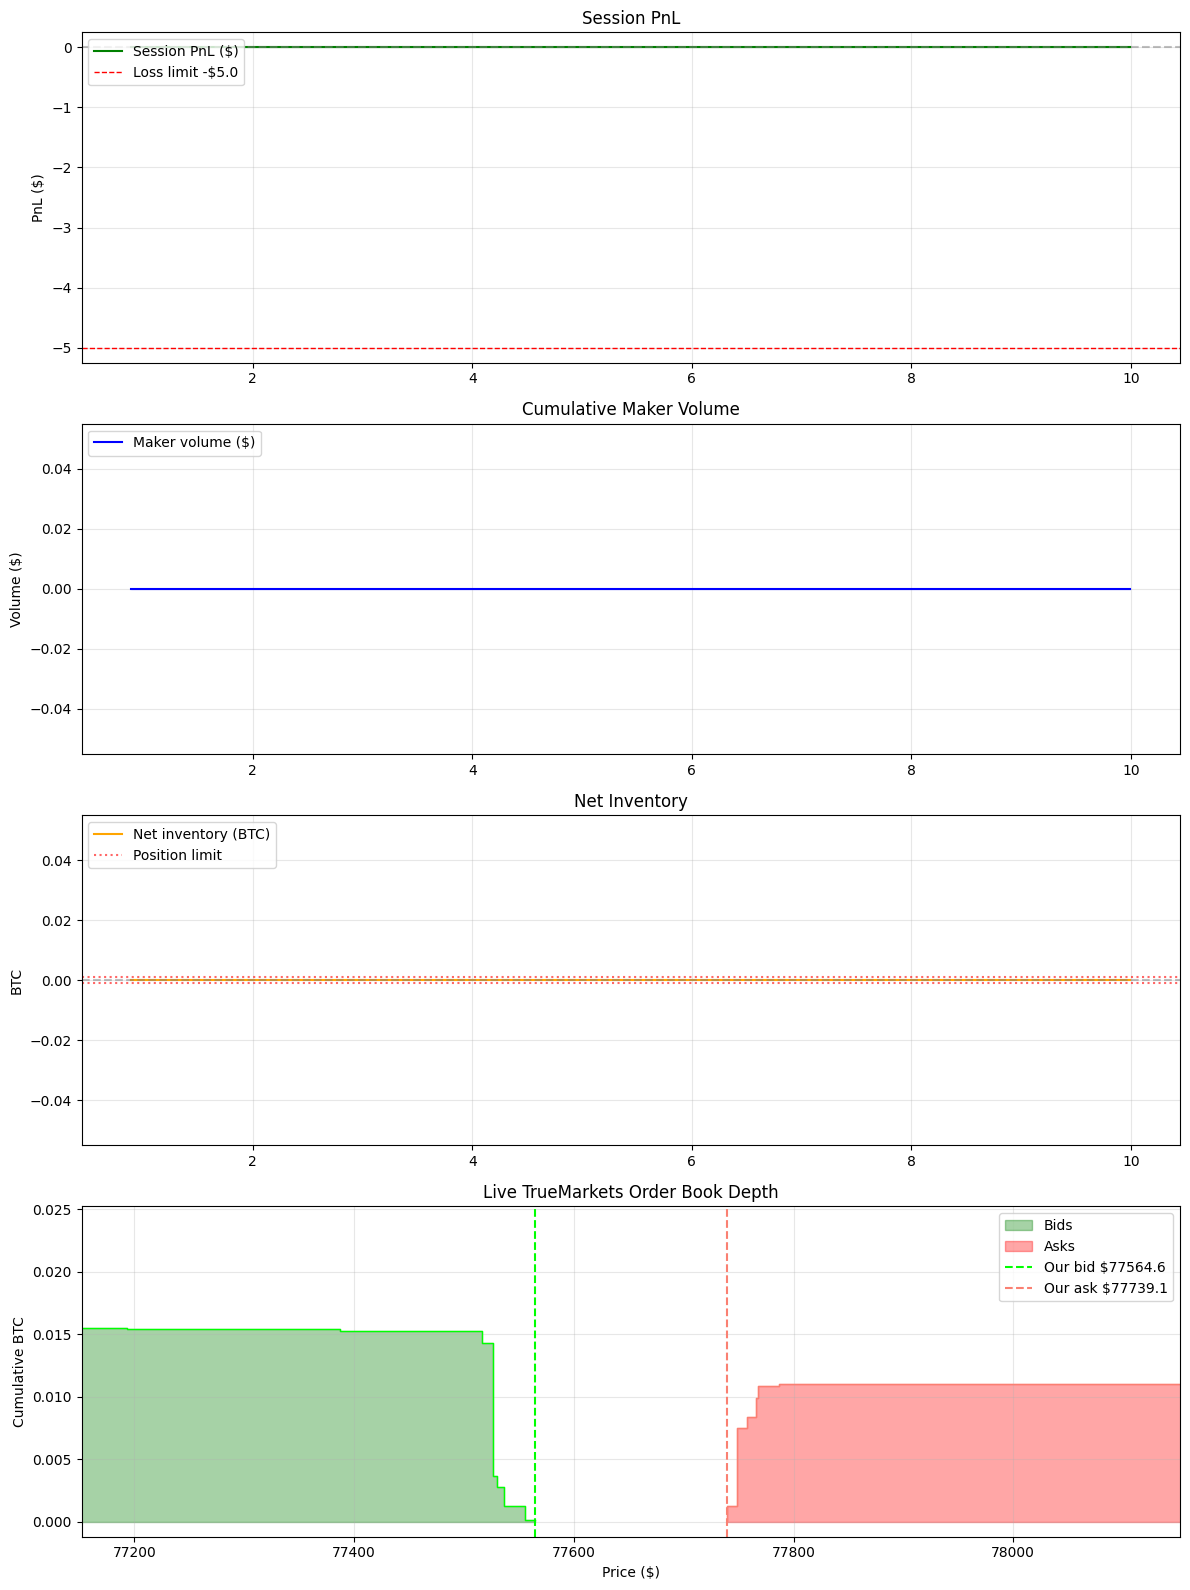

  00:54:41  ref 77555.5[0.0012]/77748.2[0.0012]  bid_spr $183.50(+9.18)  ask_spr $183.60(-9.18)  inv +0.00000  pnl $+0.0000  vol $0.00  rl 56/100
    bid: BUY  0.0001 @ 77564.6  [ref 77555.5 sz=0.00119]  |  ask: SELL 0.0001 @ 77739.1  [ref 77748.2 sz=0.00119]

Stopped.


In [6]:
# Interrupt kernel (stop button) to exit cleanly
await run_strategy()